1.1 Imports et chargement des données

In [ ]:
# Analyse et modélisation

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Affichage propre
sns.set(style="whitegrid")

In [ ]:
# Chargement des données
df = pd.read_csv("/content/projet_kobenan/detection_fraude.csv", sep=";")

print(df.head())
print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Resumé de notre dataset pour une compréhension globale.Les lignes de code (ydata-profiling et ProfileReport) permettent d'avoir une idée générale de notre jeux de donnée.



In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_5543/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
df = pd.read_csv("/content/projet_kobenan/detection_fraude.csv", sep=";")

In [ ]:
profile = ProfileReport(df)
profile

# Rapport ydata-profiling généré (output volumineux retiré du notebook pour GitHub)


In [ ]:
# Vérification du nombre de valeurs manquantes
missing_values = df.isna().sum()
print("Valeurs manquantes par variable :")
print(missing_values[missing_values > 0])

Valeurs manquantes par variable :
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
# Suppression des observations contenant au moins une valeur manquante
df = df.dropna()

In [ ]:
# Vérification après nettoyage
print("Nombre de lignes après suppression :", df.shape[0])

Nombre de lignes après suppression : 12792


1.2 Analyse descriptive du déséquilibre de classes

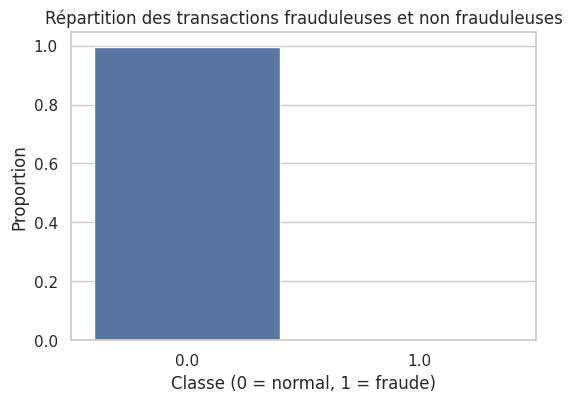

Class
0.0    0.995622
1.0    0.004378
Name: proportion, dtype: float64


In [ ]:
# Répartition des classes
class_counts = df["Class"].value_counts(normalize=True)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Répartition des transactions frauduleuses et non frauduleuses")
plt.ylabel("Proportion")
plt.xlabel("Classe (0 = normal, 1 = fraude)")
plt.show()

print(class_counts)

1.3 Analyse du montant (Amount)

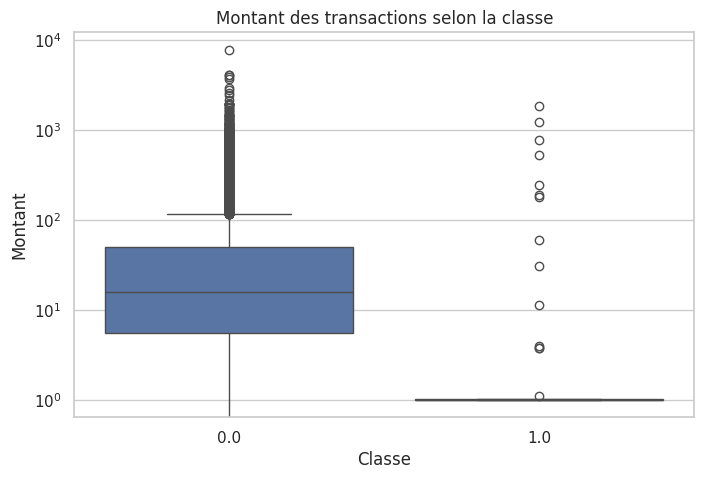

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Montant des transactions selon la classe")
plt.xlabel("Classe")
plt.ylabel("Montant")
plt.yscale("log")  # échelle logarithmique pour lisibilité
plt.show()

1.4 Préparation des données

In [ ]:
# Séparation features / cible
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Séparation apprentissage / test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8954, 30)
Test size: (3838, 30)


1.5 Régression logistique

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print("Régression logistique - Rapport de classification")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))

Régression logistique - Rapport de classification
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      3821
         1.0       0.29      0.82      0.43        17

    accuracy                           0.99      3838
   macro avg       0.65      0.91      0.71      3838
weighted avg       1.00      0.99      0.99      3838

ROC AUC: 0.9456101728835998


1.6 Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest - Rapport de classification")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest - Rapport de classification
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3821
         1.0       1.00      0.76      0.87        17

    accuracy                           1.00      3838
   macro avg       1.00      0.88      0.93      3838
weighted avg       1.00      1.00      1.00      3838

ROC AUC: 0.9994919716119894


1.7 Courbes ROC

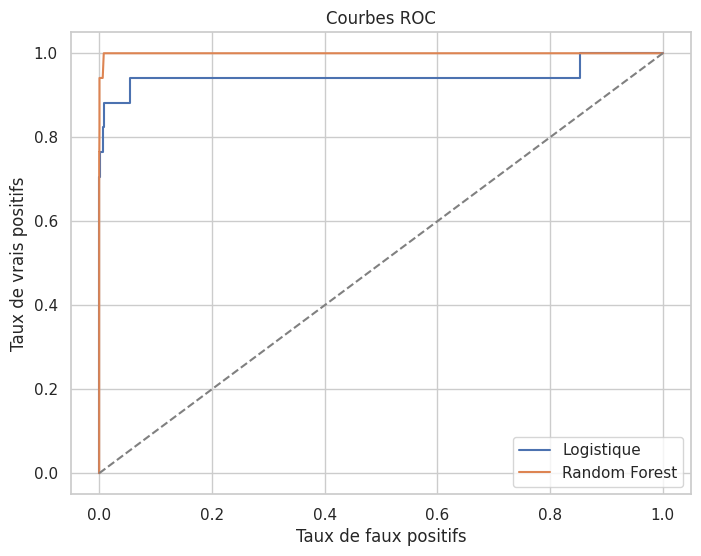

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistique")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="grey")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC")
plt.legend()
plt.show()

1.8 Importance des variables (Random Forest)

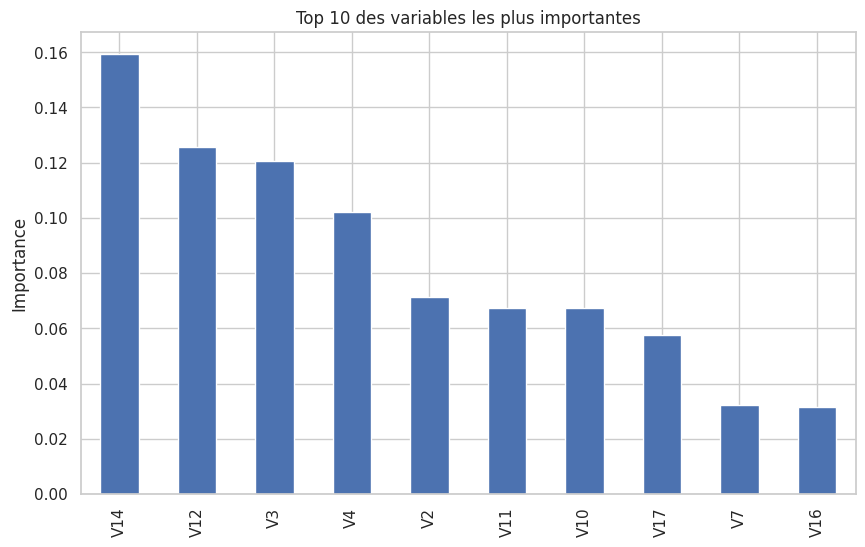

In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=df.drop("Class", axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind="bar")
plt.title("Top 10 des variables les plus importantes")
plt.ylabel("Importance")
plt.show()